# 🏦 Modelo de Teoría de Colas para Agencias Bancarias
## Sistema M/M/s → M/G/s | Optimización de Servidores

**Objetivo:** Determinar cuántos auxiliares de operaciones necesita cada agencia
por franja horaria para minimizar el costo total (espera + servidores).

---

### 📚 Marco teórico resumido

En una agencia bancaria tenemos:
- **Clientes** que llegan aleatoriamente (proceso de Poisson con tasa λ)
- **Auxiliares** que atienden (cada uno con tasa μ)
- **Cola** que se forma cuando todos están ocupados

El costo total que queremos minimizar es:
```
CT = Costo servidores ocupados + Costo servidores ociosos + Costo espera del cliente
```

Usamos dos modelos:
1. **M/M/s** → llegadas Poisson, servicios exponenciales, s servidores
2. **M/G/s (Allen-Cunneen)** → igual pero con distribución general de servicio (más realista)

---
## PASO 1 — Importar librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import random
import time
from math import factorial

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## PASO 2 — Carga de datos

Tenemos dos fuentes:
- **df.csv**: demanda por agencia y franja horaria (λ, servidores, costos)
- **dist_agencias.csv**: distribución proporcional de operaciones por hora

Ajusta las rutas si los archivos están en otra carpeta.

In [6]:
# Carga de archivos — ajusta la ruta si es necesario
df   = pd.read_csv('df.csv')
dist = pd.read_csv('dist_agencias.csv')

print('=== df.csv ===')
print(f'Dimensiones: {df.shape}')
print(df.head(10))
print()
print('=== dist_agencias.csv ===')
print(f'Dimensiones: {dist.shape}')
print(dist[['agencia','tipo_ope']].to_string())

=== df.csv ===
Dimensiones: (20, 6)
                                 agencia                 hora  lambda  servidores      Cs      Cq
0  AG.PARQUE DE LAS FLORES LOS GUINDALES  09:00:00 - 09:59:59 50.5000           5 13.6400 27.2900
1  AG.PARQUE DE LAS FLORES LOS GUINDALES  10:00:00 - 10:59:59 60.1200           5 13.6400 27.2900
2  AG.PARQUE DE LAS FLORES LOS GUINDALES  11:00:00 - 11:59:59 58.9000           5 13.6400 27.2900
3  AG.PARQUE DE LAS FLORES LOS GUINDALES  12:00:00 - 12:59:59 43.4800           5 13.6400 27.2900
4  AG.PARQUE DE LAS FLORES LOS GUINDALES  13:00:00 - 13:59:59 35.0000           5 13.6400 27.2900
5  AG.PARQUE DE LAS FLORES LOS GUINDALES  14:00:00 - 14:59:59 31.6400           5 13.6400 27.2900
6  AG.PARQUE DE LAS FLORES LOS GUINDALES  15:00:00 - 15:59:59 44.2300           5 13.6400 27.2900
7  AG.PARQUE DE LAS FLORES LOS GUINDALES  16:00:00 - 16:59:59 59.1100           5 13.6400 27.2900
8  AG.PARQUE DE LAS FLORES LOS GUINDALES  17:00:00 - 17:59:59 65.2800           5 

---
## PASO 3 — Tiempos de servicio por tipo de operación

Estos valores representan el **tiempo promedio** (en minutos) y la **varianza** que tarda
cada tipo de operación. Los usaremos para calcular μ ponderado por hora.

**¿Por qué la varianza importa?**
Porque en el mundo real las operaciones no tardan exactamente lo mismo siempre.
Un desembolso puede tardar 5 min o 10 min según el cliente.
Esa variabilidad aumenta las colas aunque la demanda promedio sea igual.
Esto lo captura el modelo M/G/s mediante el coeficiente de variación **C_s²**.

In [7]:
# Tiempo promedio de servicio por tipo de operación (minutos)
T_SERVICIO = {
    'DEPOSITO':                         2.8,
    'COBRANZA LOCALES OTRAS AGENCIAS':  2.5,
    'COBRANZAS':                        2.5,
    'RETIRO':                           3.0,
    'DESEMBOLSO':                       14.5,
    'APERTURA':                        12.0
}

# Varianza del tiempo de servicio (minutos²)
# Operaciones simples → baja varianza | complejas → alta varianza
VAR_SERVICIO = {
    'DEPOSITO':                         2.0,
    'COBRANZA LOCALES OTRAS AGENCIAS':  3.5,
    'COBRANZAS':                        3.5,
    'RETIRO':                           2.5,
    'DESEMBOLSO':                      7.0,
    'APERTURA':                        5.0
}

dist['t_s']   = dist['tipo_ope'].map(T_SERVICIO)
dist['var_s'] = dist['tipo_ope'].map(VAR_SERVICIO)

print('Parámetros de servicio asignados:')
print(dist[['agencia','tipo_ope','t_s','var_s']].drop_duplicates('tipo_ope').to_string(index=False))

Parámetros de servicio asignados:
                 agencia                        tipo_ope     t_s  var_s
AG. CIUDAD UNIVERSITARIA                        DEPOSITO  2.8000 2.0000
AG. CIUDAD UNIVERSITARIA COBRANZA LOCALES OTRAS AGENCIAS  2.5000 3.5000
AG. CIUDAD UNIVERSITARIA                       COBRANZAS  2.5000 3.5000
AG. CIUDAD UNIVERSITARIA                          RETIRO  3.0000 2.5000
AG. CIUDAD UNIVERSITARIA                      DESEMBOLSO 14.5000 7.0000
AG. CIUDAD UNIVERSITARIA                        APERTURA 12.0000 5.0000


---
## PASO 4 — Análisis Exploratorio de Datos (EDA)

Antes de modelar, siempre exploramos los datos para entender:
- ¿Cuándo hay más demanda (λ)?
- ¿Los servidores actuales son suficientes?
- ¿Hay horas críticas evidentes?

In [8]:
print('=== Estadísticas de demanda (λ) ===')
print(df.groupby('agencia')['lambda'].describe().round(2))
print()
print('=== Configuración actual de servidores ===')
print(df.groupby('agencia')['servidores'].describe().round(2))
print()
print('=== Costos por agencia ===')
print(df.groupby('agencia')[['Cs','Cq']].first().round(2))

=== Estadísticas de demanda (λ) ===
                                        count    mean     std     min     25%     50%     75%     max
agencia                                                                                              
AG. CIUDAD UNIVERSITARIA              10.0000 49.9800 14.8800 24.0000 38.8200 50.8200 62.5500 67.8300
AG.PARQUE DE LAS FLORES LOS GUINDALES 10.0000 47.1700 13.9900 23.4500 37.1200 47.3600 59.0600 65.2800

=== Configuración actual de servidores ===
                                        count   mean    std    min    25%    50%    75%    max
agencia                                                                                       
AG. CIUDAD UNIVERSITARIA              10.0000 6.0000 0.0000 6.0000 6.0000 6.0000 6.0000 6.0000
AG.PARQUE DE LAS FLORES LOS GUINDALES 10.0000 5.0000 0.0000 5.0000 5.0000 5.0000 5.0000 5.0000

=== Costos por agencia ===
                                           Cs      Cq
agencia                                           

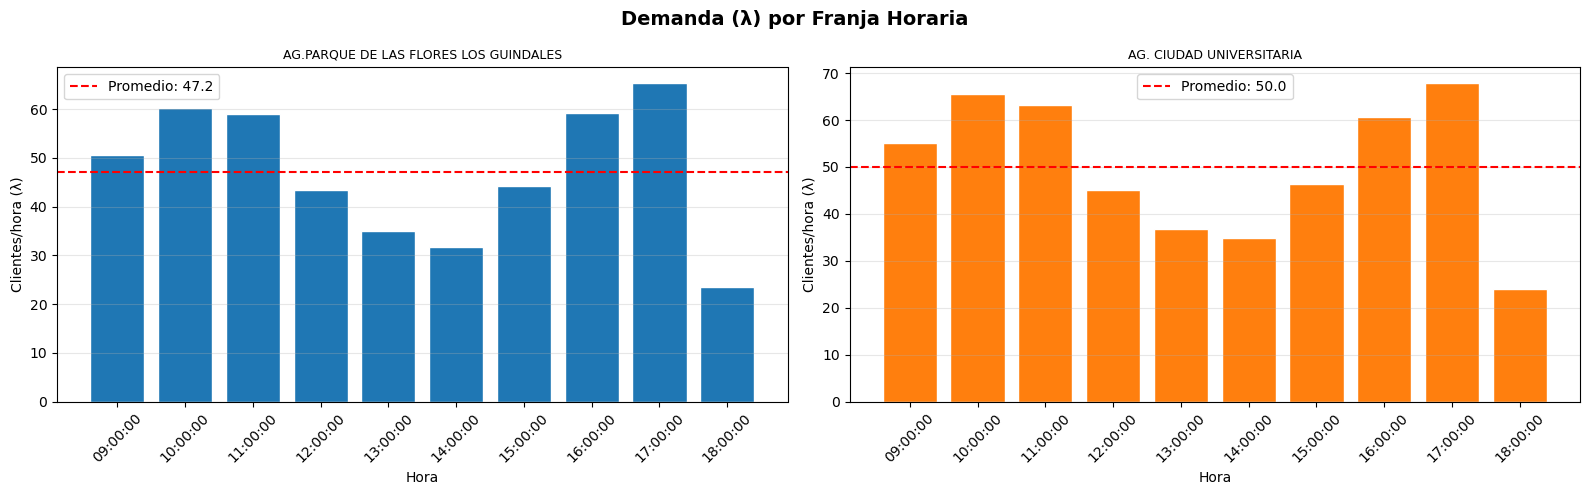

✅ Gráfico guardado: eda_demanda.png


In [9]:
cols_horas = [c for c in dist.columns if ':' in c]
agencias   = df['agencia'].unique()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demanda (λ) por Franja Horaria', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, ['#1f77b4','#ff7f0e']):
    sub = df[df['agencia'] == agencia].copy()
    horas_cortas = [h.split(' ')[0] for h in sub['hora']]
    ax.bar(horas_cortas, sub['lambda'], color=color, edgecolor='white')
    ax.axhline(sub['lambda'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f"Promedio: {sub['lambda'].mean():.1f}")
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_xlabel('Hora')
    ax.set_ylabel('Clientes/hora (λ)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_demanda.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: eda_demanda.png')

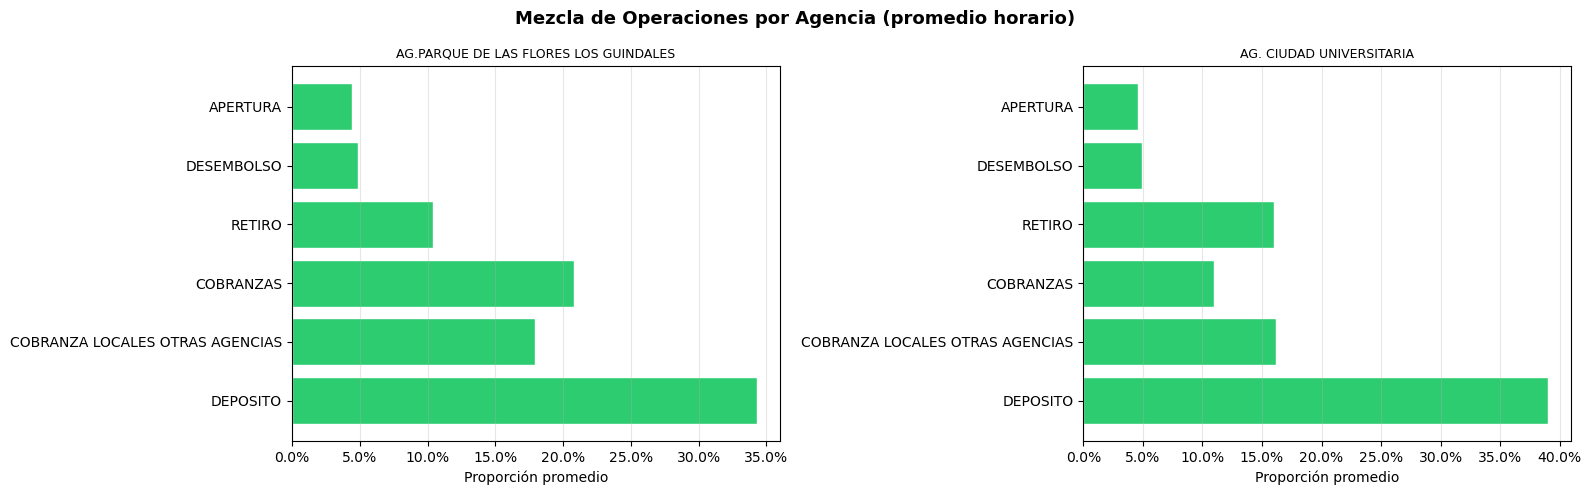

✅ Gráfico guardado: eda_operaciones.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mezcla de Operaciones por Agencia (promedio horario)', fontsize=13, fontweight='bold')

for ax, agencia in zip(axes, agencias):
    sub = dist[dist['agencia'] == agencia].copy()
    sub['prop_media'] = sub[cols_horas].mean(axis=1)
    ax.barh(sub['tipo_ope'], sub['prop_media'], color='#2ecc71', edgecolor='white')
    ax.set_title(agencia[:38], fontsize=9)
    ax.set_xlabel('Proporción promedio')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_operaciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: eda_operaciones.png')

---
## PASO 5 — Cálculo de μ (tasa de servicio) y C_s² ponderados

### ¿Qué es μ?
μ es cuántos clientes puede atender **un solo auxiliar** en una hora.
Como la mezcla de operaciones cambia cada hora, μ también cambia.

**Fórmulas:**
```
E(T)  = Σ [ p_k(hora) × t_k ]          ← tiempo promedio ponderado (minutos)
μ     = 60 / E(T)                        ← clientes por hora
E(T²) = Σ [ p_k × (Var_k + t_k²) ]     ← ley de expectativas totales
Var(T)= E(T²) - [E(T)]²
C_s²  = Var(T) / [E(T)]²                ← coeficiente de variación al cuadrado
```

**Interpretación de C_s²:**
- C_s² = 1 → distribución exponencial (M/M/s exacto)
- C_s² < 1 → tiempos más regulares → colas menores ✅
- C_s² > 1 → tiempos más variables → colas mayores ⚠️

In [11]:
def calcular_mu_C_s2(df_base, dist_df, cols_horas):
    """
    Para cada fila (agencia + hora) calcula mu y C_s².
    
    E[T] es el tiempo promedio ponderado por la mezcla de operaciones.
    C_s² captura la variabilidad de los tiempos de servicio.
    """
    rows = []
    for _, row in df_base.iterrows():
        agencia = row['agencia']
        hora    = row['hora']
        d       = dist_df[dist_df['agencia'] == agencia]
        probs   = d[hora].values.astype(float)
        ts      = d['t_s'].values.astype(float)
        var_s   = d['var_s'].values.astype(float)
        total_p = probs.sum()
        
        if total_p == 0 or np.isnan(total_p):
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan})
            continue
        
        E_T   = np.dot(probs, ts) / total_p
        E_T2  = np.dot(probs, var_s + ts**2) / total_p
        Var_T = E_T2 - E_T**2
        C_s2  = Var_T / E_T**2 if E_T > 0 else np.nan
        mu    = 60.0 / E_T   if E_T > 0 else np.nan
        rows.append({'agencia': agencia, 'hora': hora, 'mu': mu, 'C_s2': C_s2})
    
    return pd.DataFrame(rows)


mu_df = calcular_mu_C_s2(df, dist, cols_horas)
df2   = df.merge(mu_df, on=['agencia','hora'], how='left')

print('μ y C_s² calculados por agencia-hora:')
print(df2[['agencia','hora','lambda','servidores','mu','C_s2']].to_string(index=False))

μ y C_s² calculados por agencia-hora:
                              agencia                hora  lambda  servidores      mu   C_s2
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 17.5240 0.8816
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 16.9105 0.9104
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 16.7368 0.9198
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 16.0419 0.9459
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 16.2433 0.9510
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 16.5562 0.9379
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 16.9340 0.8952
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 16.7865 0.9139
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2800           5 15.3283 0.9829
AG.PARQUE DE LAS FLORES LOS GUIN

---
## PASO 6 — Modelo M/M/s

### Fórmulas del modelo M/M/s

**ρ (utilización):**  ρ = λ / (s × μ)    debe ser < 1

**P₀ (prob. sistema vacío):**
```
P₀ = 1 / [ Σ(k=0..s-1)(r^k/k!) + r^s/(s!×(1−ρ)) ]   donde r = λ/μ
```

**Lq (clientes en cola):**
```
Lq = P₀ × r^s × ρ / (s! × (1−ρ)²)
```

**Tiempos:**   Wq = Lq/λ  |  Ws = Wq + 1/μ  |  Ls = λ×Ws

**Costos:**
```
CTS      = (Cs + Cq) × (Ls - Lq)     ← servidores ocupados
CTS_idle = Cs × (s - (Ls - Lq))      ← servidores ociosos
CTQ      = λ × Cq × Wq               ← costo de espera
CT       = CTS + CTS_idle + CTQ       ← COSTO TOTAL
```

In [12]:
def mms_metricas(lam, mu, c, Cs, Cq):
    """
    Calcula las 14 métricas del modelo M/M/s.
    Devuelve dict con NaN si el sistema es inválido o inestable (rho >= 1).
    """
    nan_r = dict(rho=np.nan,P0=np.nan,Lq=np.nan,Wq_h=np.nan,Ws_h=np.nan,
                 Ls=np.nan,Wq_m=np.nan,Ws_m=np.nan,serv_ocupados=np.nan,
                 serv_ociosos=np.nan,CTS=np.nan,CTS_idle=np.nan,CTQ=np.nan,CT=np.nan)
    
    if mu <= 0 or c <= 0 or lam < 0:
        return nan_r
    
    c   = int(c)
    rho = lam / (c * mu)
    r   = lam / mu
    
    if rho >= 1:
        return {**nan_r, 'rho': rho}  # sistema inestable
    
    # P0: probabilidad de sistema vacío
    sum_k  = sum(r**k / factorial(k) for k in range(c))
    term_c = (r**c) / (factorial(c) * (1 - rho))
    P0     = 1.0 / (sum_k + term_c)
    
    # Cola
    Lq   = P0 * (r**c) * rho / (factorial(c) * (1 - rho)**2)
    Wq_h = Lq / lam
    Ws_h = Wq_h + 1.0/mu
    Ls   = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60
    
    # Servidores
    serv_ocupados = Ls - Lq
    serv_ociosos  = c - serv_ocupados
    
    # Costos
    CTS      = (Cs + Cq) * serv_ocupados
    CTS_idle = Cs * serv_ociosos
    CTQ      = lam * Cq * Wq_h
    CT       = CTS + CTS_idle + CTQ
    
    return dict(rho=rho,P0=P0,Lq=Lq,Wq_h=Wq_h,Ws_h=Ws_h,Ls=Ls,
                Wq_m=Wq_m,Ws_m=Ws_m,serv_ocupados=serv_ocupados,
                serv_ociosos=serv_ociosos,CTS=CTS,CTS_idle=CTS_idle,CTQ=CTQ,CT=CT)

# Prueba
fila = df2.iloc[0]
res  = mms_metricas(fila['lambda'],fila['mu'],fila['servidores'],fila['Cs'],fila['Cq'])
print(f'=== Prueba M/M/s ===')
print(f'Agencia : {fila["agencia"]}')
print(f'Hora    : {fila["hora"]}')
print(f'λ={fila["lambda"]:.1f}  μ={fila["mu"]:.2f}  s={fila["servidores"]}')
print()
for k,v in res.items():
    print(f'  {k:20s}: {v:.4f}' if not np.isnan(v) else f'  {k:20s}: NaN')

=== Prueba M/M/s ===
Agencia : AG.PARQUE DE LAS FLORES LOS GUINDALES
Hora    : 09:00:00 - 09:59:59
λ=50.5  μ=17.52  s=5

  rho                 : 0.5764
  P0                  : 0.0532
  Lq                  : 0.2828
  Wq_h                : 0.0056
  Ws_h                : 0.0627
  Ls                  : 3.1646
  Wq_m                : 0.3360
  Ws_m                : 3.7599
  serv_ocupados       : 2.8818
  serv_ociosos        : 2.1182
  CTS                 : 117.9507
  CTS_idle            : 28.8927
  CTQ                 : 7.7181
  CT                  : 154.5615


---
## PASO 7 — Extensión a M/G/s (Allen-Cunneen)

El M/M/s asume servicios **exponenciales** (C_s²=1).
La realidad bancaria tiene variabilidad diferente → usamos la corrección:

```
Wq_MGs = Wq_MMs × (1 + C_s²) / 2
```

Con nuestros datos C_s² ≈ 0.33 → factor ≈ 0.66
→ las colas reales son un **34% menores** que lo que estimaría M/M/s puro.
→ Esto hace al modelo más conservador y adecuado para decisiones de negocio.

In [13]:
def mgs_metricas(lam, mu, c, Cs, Cq, C_s2):
    """
    Modelo M/G/s via Allen-Cunneen.
    Wq_MGs = Wq_MMs × (1 + C_s²) / 2
    Si C_s2 no disponible se usa 1.0 (equivalente a M/M/s).
    """
    base = mms_metricas(lam, mu, c, Cs, Cq)
    nan_ext = dict(Wq_h_mg=np.nan,Ws_h_mg=np.nan,Wq_m_mg=np.nan,
                   Ws_m_mg=np.nan,Lq_mg=np.nan,Ls_mg=np.nan,CT_mg=np.nan,CTQ_mg=np.nan)
    
    if np.isnan(base['Wq_h']):
        return {**base, **nan_ext}
    
    cs2    = C_s2 if (not np.isnan(C_s2) and C_s2 >= 0) else 1.0
    factor = (1.0 + cs2) / 2.0
    
    Wq_h_mg = base['Wq_h'] * factor
    Ws_h_mg = Wq_h_mg + 1.0/mu
    Lq_mg   = lam * Wq_h_mg
    Ls_mg   = lam * Ws_h_mg
    CTQ_mg  = lam * Cq * Wq_h_mg
    CT_mg   = base['CTS'] + base['CTS_idle'] + CTQ_mg
    
    return {**base,
            'Wq_h_mg':Wq_h_mg,'Ws_h_mg':Ws_h_mg,
            'Wq_m_mg':Wq_h_mg*60,'Ws_m_mg':Ws_h_mg*60,
            'Lq_mg':Lq_mg,'Ls_mg':Ls_mg,'CT_mg':CT_mg,'CTQ_mg':CTQ_mg}

# Comparación en la primera fila
fila   = df2.iloc[0]
res_mg = mgs_metricas(fila['lambda'],fila['mu'],fila['servidores'],
                      fila['Cs'],fila['Cq'],fila['C_s2'])

print('=== Comparación M/M/s vs M/G/s ===')
print(f'C_s² = {fila["C_s2"]:.4f}  →  factor Allen-Cunneen = {(1+fila["C_s2"])/2:.4f}')
print()
print(f'  Wq (M/M/s) = {res_mg["Wq_m"]:.2f} min')
print(f'  Wq (M/G/s) = {res_mg["Wq_m_mg"]:.2f} min  ← más realista')
print(f'  CT (M/M/s) = S/. {res_mg["CT"]:.2f}')
print(f'  CT (M/G/s) = S/. {res_mg["CT_mg"]:.2f}')

=== Comparación M/M/s vs M/G/s ===
C_s² = 0.8816  →  factor Allen-Cunneen = 0.9408

  Wq (M/M/s) = 0.34 min
  Wq (M/G/s) = 0.32 min  ← más realista
  CT (M/M/s) = S/. 154.56
  CT (M/G/s) = S/. 154.10


---
## PASO 8 — Búsqueda del número óptimo de servidores

Para cada agencia-hora evaluamos de 1 a 15 servidores y elegimos el que **minimiza CT**.

**Lógica del negocio:**
- Pocos servidores → cola larga → CTQ alto
- Muchos servidores → CTS_idle alto
- El óptimo balancea ambos costos

Responde la pregunta gerencial: **¿Vale la pena contratar un auxiliar adicional?**

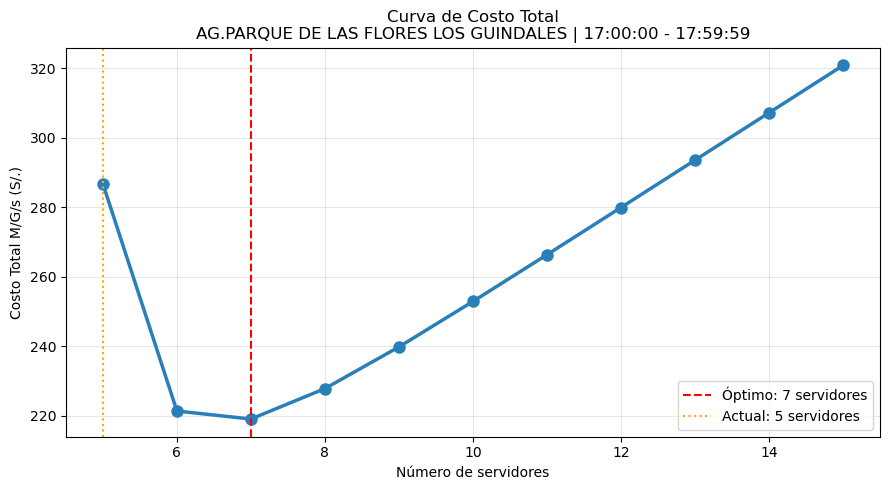

✅ Óptimo: 7 servidores | CT = S/. 219.04


In [14]:
def servidores_optimos(lam, mu, Cs, Cq, C_s2, max_s=15):
    """Busca el s que minimiza CT via M/G/s. Retorna (s_opt, ct_opt, curva)."""
    r      = lam / mu if mu > 0 else np.inf
    best   = np.inf
    best_s = max(1, int(np.ceil(r)) + 1)
    curva  = []
    for s in range(1, max_s + 1):
        m  = mgs_metricas(lam, mu, s, Cs, Cq, C_s2)
        ct = m['CT_mg']
        if not np.isnan(ct):
            curva.append((s, ct))
            if ct < best:
                best, best_s = ct, s
    return best_s, best, curva

# Curva de costo para la hora más crítica (fila 8: 17:00)
fila = df2.iloc[8]
s_opt, ct_opt, curva = servidores_optimos(
    fila['lambda'],fila['mu'],fila['Cs'],fila['Cq'],fila['C_s2'])

s_vals  = [x[0] for x in curva]
ct_vals = [x[1] for x in curva]

plt.figure(figsize=(9,5))
plt.plot(s_vals, ct_vals, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
plt.axvline(s_opt, color='red', linestyle='--', linewidth=1.5, label=f'Óptimo: {s_opt} servidores')
plt.axvline(fila['servidores'], color='orange', linestyle=':', linewidth=1.5,
            label=f'Actual: {int(fila["servidores"])} servidores')
plt.xlabel('Número de servidores')
plt.ylabel('Costo Total M/G/s (S/.)')
plt.title(f'Curva de Costo Total\n{fila["agencia"][:45]} | {fila["hora"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('curva_costo_optimo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Óptimo: {s_opt} servidores | CT = S/. {ct_opt:.2f}')

---
## PASO 9 — Aplicar modelo a todas las agencias y franjas horarias

In [21]:
resultados = []

for _, row in df2.iterrows():
    lam, mu, c = row['lambda'], row['mu'], row['servidores']
    Cs, Cq, C_s2 = row['Cs'], row['Cq'], row['C_s2']
    
    m_actual            = mgs_metricas(lam, mu, c, Cs, Cq, C_s2)
    s_opt, ct_opt, _    = servidores_optimos(lam, mu, Cs, Cq, C_s2)
    m_opt               = mgs_metricas(lam, mu, s_opt, Cs, Cq, C_s2)
    
    diff = s_opt - c
    decision = f'CONTRATAR {diff}' if diff>0 else (f'REDUCIR {abs(diff)}' if diff<0 else 'MANTENER')
    ahorro   = (m_actual['CT_mg'] - ct_opt) if not np.isnan(m_actual['CT_mg']) else np.nan
    
    def r(v): return round(v,4) if not np.isnan(v) else np.nan
    def r2(v): return round(v,2) if not np.isnan(v) else np.nan
    
    rec = {
        'agencia': row['agencia'], 'hora': row['hora'],
        'lambda': round(lam,2), 'mu': r(mu), 'C_s2': r(C_s2),
        'Cs': Cs, 'Cq': Cq,
        'servidores_actuales': int(c), 'servidores_optimos': s_opt, 'decision': decision,
        # M/M/s
        'rho': r(m_actual['rho']), 'P0': r(m_actual['P0']),
        'Lq_mms': r(m_actual['Lq']), 'Wq_m_mms': r(m_actual['Wq_m']),
        'Ws_m_mms': r(m_actual['Ws_m']), 'Ls_mms': r(m_actual['Ls']),
        # M/G/s actual
        'Lq_mgs': r(m_actual['Lq_mg']), 'Wq_m_mgs': r(m_actual['Wq_m_mg']),
        'Ws_m_mgs': r(m_actual['Ws_m_mg']), 'Ls_mgs': r(m_actual['Ls_mg']),
        # Servidores
        'serv_ocupados': r(m_actual['serv_ocupados']),
        'serv_ociosos': r(m_actual['serv_ociosos']),
        # Costos
        'CTS': r2(m_actual['CTS']), 'CTS_idle': r2(m_actual['CTS_idle']),
        'CTQ_mgs': r2(m_actual['CTQ_mg']), 'CT_actual': r2(m_actual['CT_mg']),
        # Óptimo
        'CT_optimo': r2(ct_opt),
        'Wq_m_optimo': r2(m_opt['Wq_m_mg']),
        'ahorro_potencial': r2(ahorro),
        'contratar_auxiliar': 'SÍ' if s_opt>c else 'NO',
        'util_pct': round(m_actual['rho']*100,1) if not np.isnan(m_actual['rho']) else np.nan,
    }
    resultados.append(rec)

result_df = pd.DataFrame(resultados)

print('=== Resumen de decisiones ===')
print(result_df[['agencia','hora','servidores_actuales','servidores_optimos',
                  'CT_actual','CT_optimo','ahorro_potencial','decision']].to_string(index=False))

=== Resumen de decisiones ===
                              agencia                hora  servidores_actuales  servidores_optimos  CT_actual  CT_optimo  ahorro_potencial    decision
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59                    5                   5   154.1000   154.1000            0.0000    MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59                    5                   6   190.6000   185.9800            4.6200 CONTRATAR 1
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59                    5                   6   188.1400   184.6100            3.5400 CONTRATAR 1
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59                    5                   5   147.5300   147.5300            0.0000    MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59                    5                   4   128.5700   120.0200            8.5500   REDUCIR 1
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59       

---
## PASO 10 — Análisis de sensibilidad

¿Qué pasa con el costo y el óptimo si la demanda varía en ±20%?
Esto permite al gerente planificar para diferentes escenarios.

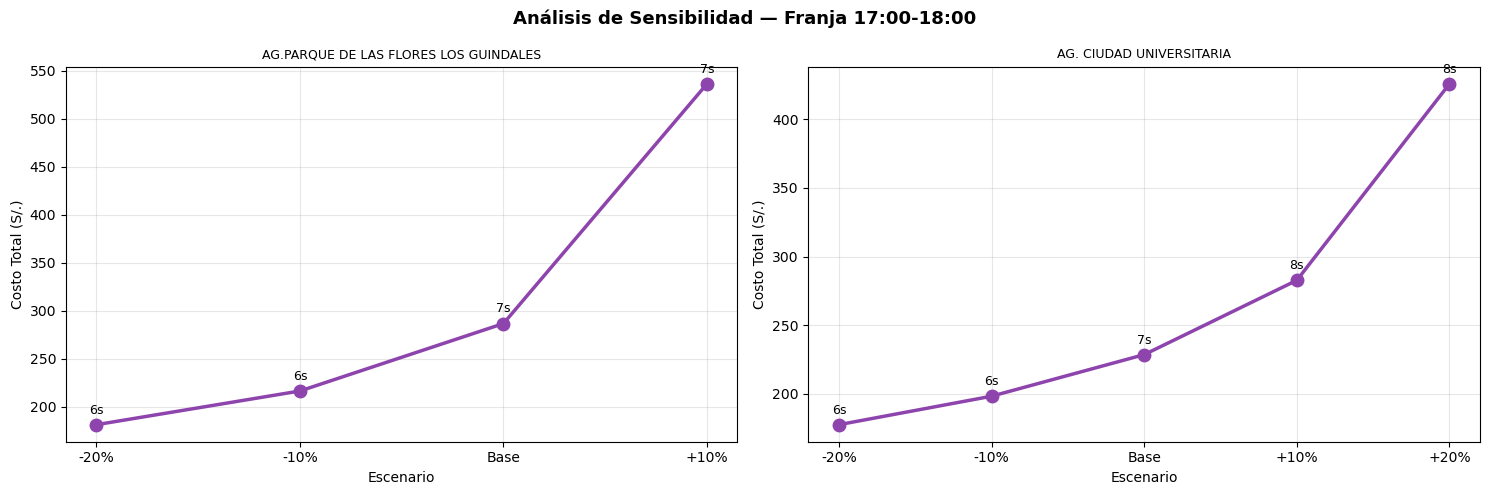

✅ Gráfico guardado: sensibilidad.png


In [15]:
factores = [0.80, 0.90, 1.00, 1.10, 1.20]
labels   = ['-20%', '-10%', 'Base', '+10%', '+20%']

sens_rows = []
for _, row in df2.iterrows():
    for factor, label in zip(factores, labels):
        lam_var = row['lambda'] * factor
        m       = mgs_metricas(lam_var,row['mu'],row['servidores'],row['Cs'],row['Cq'],row['C_s2'])
        s_opt,ct_opt,_ = servidores_optimos(lam_var,row['mu'],row['Cs'],row['Cq'],row['C_s2'])
        sens_rows.append({
            'agencia': row['agencia'], 'hora': row['hora'], 'escenario': label,
            'lambda_var': round(lam_var,2),
            'CT_var': round(m['CT_mg'],2) if not np.isnan(m['CT_mg']) else np.nan,
            'Wq_m_var': round(m['Wq_m_mg'],2) if not np.isnan(m['Wq_m_mg']) else np.nan,
            's_opt_var': s_opt,
        })

sens_df = pd.DataFrame(sens_rows)

# Visualización para la hora pico 17:00
fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle('Análisis de Sensibilidad — Franja 17:00-18:00', fontsize=13, fontweight='bold')

for ax, agencia in zip(axes, df2['agencia'].unique()):
    sub = sens_df[(sens_df['agencia']==agencia) & (sens_df['hora']=='17:00:00 - 17:59:59')]
    ax.plot(sub['escenario'], sub['CT_var'], 'o-', color='#8e44ad', linewidth=2.5, markersize=9)
    for _, r in sub.iterrows():
        ax.annotate(f"{r['s_opt_var']}s",(r['escenario'],r['CT_var']),
                    textcoords='offset points',xytext=(0,8),ha='center',fontsize=9)
    ax.set_title(agencia[:38],fontsize=9)
    ax.set_xlabel('Escenario')
    ax.set_ylabel('Costo Total (S/.)')
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('sensibilidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: sensibilidad.png')

---
## PASO 11 — Simulación Monte Carlo

### ¿Por qué Monte Carlo y no solo fórmulas analíticas?

Los modelos M/M/s y M/G/s calculan el **estado estacionario** del sistema (el promedio a largo plazo).
Pero en la realidad bancaria:

- La jornada dura solo **10 horas** → el sistema nunca alcanza el estado estacionario
- Las llegadas son **aleatorias**: a veces llegan 3 clientes seguidos, a veces 0
- Los tiempos de servicio varían **operación por operación**

La simulación Monte Carlo replica este comportamiento **N veces** y nos da:
- **Distribuciones** de Wq, Lq, utilización (no solo promedios)
- **Intervalos de confianza** al 95%
- **Percentiles** (p50, p90, p95) → críticos para establecer metas de servicio
- **Validación** de los resultados analíticos

### Cómo funciona nuestra simulación:
1. Generamos llegadas con proceso Poisson (intervalos ~ Exp(λ))
2. Asignamos tipo de operación según la distribución de mezcla real
3. Generamos tiempos de servicio con distribución Gamma calibrada (media E[T], varianza Var(T))
4. Los clientes hacen cola y son atendidos por `s` servidores en paralelo
5. Repetimos `N_REP` veces → obtenemos distribución de resultados


In [16]:
# ════════════════════════════════════════════════════════════
# SIMULACIÓN MONTE CARLO — Función Principal
# ════════════════════════════════════════════════════════════

def gamma_params(mean_min, var_min):
    """
    Convierte E[T] y Var(T) en parámetros de distribución Gamma.
    
    La distribución Gamma es perfecta para modelar tiempos de servicio:
    - Solo toma valores positivos (un servicio nunca dura tiempo negativo)
    - Puede ser simétrica o asimétrica según k y theta
    
    Forma: X ~ Gamma(k, theta)
    - k     = shape = E[T]² / Var(T)
    - theta = scale = Var(T) / E[T]
    """
    if var_min <= 0 or mean_min <= 0:
        return None, None  # caso degenerado
    k     = (mean_min ** 2) / var_min
    theta = var_min / mean_min
    return k, theta


def simular_cola_mc(lam, mu, s, t_operaciones, dist_hora, n_rep=300, duracion_h=1.0, seed=42):
    """
    Simulación Monte Carlo de cola M/G/s para una agencia-hora.
    
    Parámetros:
    -----------
    lam         : tasa de llegada (clientes/hora)
    mu          : tasa de servicio ponderada (clientes/hora) — solo para referencia
    s           : número de servidores
    t_operaciones: dict {tipo: (media_min, var_min)} con parámetros de tiempo de servicio
    dist_hora   : dict {tipo: prob} con la distribución de mezcla de la hora
    n_rep       : número de réplicas Monte Carlo
    duracion_h  : duración de la simulación en horas
    seed        : semilla para reproducibilidad
    
    Retorna:
    --------
    dict con estadísticas: media, std, percentiles, intervalo de confianza
    """
    rng = np.random.default_rng(seed)
    duracion_min = duracion_h * 60.0
    
    # Preparar parámetros Gamma por tipo de operación
    gamma_par = {}
    for tipo, (media, var) in t_operaciones.items():
        k, theta = gamma_params(media, var)
        gamma_par[tipo] = (k, theta)
    
    # Tipos y probabilidades de operación (normalizadas)
    tipos = list(dist_hora.keys())
    probs = np.array([dist_hora[t] for t in tipos], dtype=float)
    probs = probs / probs.sum()
    
    metricas_rep = {
        'Wq_m': [], 'Ws_m': [], 'util': [],
        'Lq': [], 'clientes_atendidos': [], 'p_espera': []
    }
    
    for rep in range(n_rep):
        seed_r = seed + rep * 1000
        rng2   = np.random.default_rng(seed_r)
        
        # ── Generación de llegadas (proceso Poisson) ──
        t_llegada = 0.0
        llegadas  = []
        while True:
            inter_llegada = rng2.exponential(1.0 / lam * 60.0)  # en minutos
            t_llegada    += inter_llegada
            if t_llegada > duracion_min:
                break
            llegadas.append(t_llegada)
        
        if len(llegadas) == 0:
            continue
        
        # ── Asignar tipo y tiempo de servicio a cada cliente ──
        n_clientes  = len(llegadas)
        tipos_asig  = rng2.choice(tipos, size=n_clientes, p=probs)
        
        t_servicio = np.zeros(n_clientes)
        for i, tipo in enumerate(tipos_asig):
            k, theta = gamma_par.get(tipo, (1.0, 1.0/mu*60))
            if k and theta:
                t_s = rng2.gamma(shape=k, scale=theta)
            else:
                t_s = rng2.exponential(1.0/mu*60)
            t_servicio[i] = max(0.01, t_s)
        
        # ── Simular colas con s servidores (Event-Driven) ──
        # fin_servicio[j] = momento en que el servidor j queda libre
        fin_servicio = np.zeros(s)  # todos libres al inicio
        
        tiempos_espera = []
        tiempos_sistema = []
        t_ocupado = np.zeros(s)  # tiempo total ocupado por servidor
        
        for i in range(n_clientes):
            t_llega  = llegadas[i]
            t_serv   = t_servicio[i]
            
            # Servidor disponible más pronto
            j_libre  = np.argmin(fin_servicio)
            t_inicio = max(t_llega, fin_servicio[j_libre])
            t_fin    = t_inicio + t_serv
            
            espera = t_inicio - t_llega
            tiempos_espera.append(espera)
            tiempos_sistema.append(t_fin - t_llega)
            
            fin_servicio[j_libre] = t_fin
            t_ocupado[j_libre] += t_serv
        
        # ── Métricas de la réplica ──
        arr_wq   = np.array(tiempos_espera)
        arr_ws   = np.array(tiempos_sistema)
        
        metricas_rep['Wq_m'].append(arr_wq.mean())
        metricas_rep['Ws_m'].append(arr_ws.mean())
        metricas_rep['Lq'].append((arr_wq > 0).sum() / duracion_min)  # aprox. clientes en cola
        metricas_rep['util'].append(t_ocupado.sum() / (s * duracion_min))
        metricas_rep['clientes_atendidos'].append(n_clientes)
        metricas_rep['p_espera'].append((arr_wq > 0).mean())
    
    # ── Consolidar resultados de N réplicas ──
    def stats(arr):
        a   = np.array(arr)
        n   = len(a)
        mu_ = a.mean()
        se  = a.std(ddof=1) / np.sqrt(n)
        z   = 1.96  # 95% confianza
        return {
            'media': round(mu_,4), 'std': round(a.std(ddof=1),4),
            'ci_low': round(mu_ - z*se, 4), 'ci_high': round(mu_ + z*se, 4),
            'p50': round(np.percentile(a,50),4),
            'p90': round(np.percentile(a,90),4),
            'p95': round(np.percentile(a,95),4),
            'min': round(a.min(),4), 'max': round(a.max(),4)
        }
    
    return {
        k: stats(v) for k,v in metricas_rep.items() if len(v) > 0
    }


print('✅ Función de simulación Monte Carlo definida')
print()
print('Parámetros de distribución Gamma por tipo de operación:')
print(f'  {"Tipo":<38} {"E[T]":>6} {"Var":>6} {"k":>6} {"theta":>6}')
print('-'*65)
for tipo, mean_val in T_SERVICIO.items():
    var_val = VAR_SERVICIO[tipo]
    k, theta = gamma_params(mean_val, var_val)
    print(f'  {tipo:<38} {mean_val:>6.1f} {var_val:>6.1f} {k:>6.2f} {theta:>6.2f}')


✅ Función de simulación Monte Carlo definida

Parámetros de distribución Gamma por tipo de operación:
  Tipo                                     E[T]    Var      k  theta
-----------------------------------------------------------------
  DEPOSITO                                  2.8    2.0   3.92   0.71
  COBRANZA LOCALES OTRAS AGENCIAS           2.5    3.5   1.79   1.40
  COBRANZAS                                 2.5    3.5   1.79   1.40
  RETIRO                                    3.0    2.5   3.60   0.83
  DESEMBOLSO                               14.5    7.0  30.04   0.48
  APERTURA                                 12.0    5.0  28.80   0.42


In [17]:
# ════════════════════════════════════════════════════════════
# EJECUTAR SIMULACIÓN PARA TODAS LAS AGENCIAS-HORAS
# ════════════════════════════════════════════════════════════

# Construir dict de parámetros de tiempo por tipo
t_ops = {tipo: (T_SERVICIO[tipo], VAR_SERVICIO[tipo]) for tipo in T_SERVICIO}

N_REP = 500  # Réplicas Monte Carlo — 500 da buena precisión sin demorar mucho
# ⚠️  Para análisis de producción se recomienda N_REP = 1000

print(f'🎲 Ejecutando {N_REP} réplicas Monte Carlo por franja horaria...')
print()

mc_resultados = []
total = len(df2)
t0 = time.time()

for idx, row in df2.iterrows():
    agencia = row['agencia']
    hora    = row['hora']
    
    # Distribución de mezcla para esta agencia-hora
    sub_dist = dist[dist['agencia'] == agencia]
    dist_hora_dict = {
        r2['tipo_ope']: float(r2[hora])
        for _, r2 in sub_dist.iterrows()
        if float(r2[hora]) > 0
    }
    
    if not dist_hora_dict:
        continue
    
    # Ejecutar simulación
    res_mc = simular_cola_mc(
        lam        = row['lambda'],
        mu         = row['mu'],
        s          = int(row['servidores']),
        t_operaciones = t_ops,
        dist_hora  = dist_hora_dict,
        n_rep      = N_REP,
        duracion_h = 1.0,
        seed       = idx * 13 + 7
    )
    
    # Comparación analítico vs simulado
    mg_res = mgs_metricas(row['lambda'], row['mu'], row['servidores'],
                          row['Cs'], row['Cq'], row['C_s2'])
    
    mc_row = {
        'agencia': agencia,
        'hora': hora,
        'lambda': row['lambda'],
        'servidores': int(row['servidores']),
        # Simulado
        'Wq_sim_media':   res_mc['Wq_m']['media'],
        'Wq_sim_std':     res_mc['Wq_m']['std'],
        'Wq_sim_ci_low':  res_mc['Wq_m']['ci_low'],
        'Wq_sim_ci_high': res_mc['Wq_m']['ci_high'],
        'Wq_sim_p50':     res_mc['Wq_m']['p50'],
        'Wq_sim_p90':     res_mc['Wq_m']['p90'],
        'Wq_sim_p95':     res_mc['Wq_m']['p95'],
        'Ws_sim_media':   res_mc['Ws_m']['media'],
        'util_sim':       res_mc['util']['media'],
        'util_sim_std':   res_mc['util']['std'],
        'p_espera_sim':   res_mc['p_espera']['media'],
        # Analítico M/G/s
        'Wq_mgs_analitico': mg_res['Wq_m_mg'],
        'rho_analitico':    mg_res['rho'],
    }
    mc_resultados.append(mc_row)
    print(f'  [{idx+1:2d}/{total}] {agencia[:28]:<28} {hora[:5]}  '
          f'Wq_sim={res_mc["Wq_m"]["media"]:5.2f}±{res_mc["Wq_m"]["std"]:4.2f} min  '
          f'Wq_analitico={mg_res["Wq_m_mg"] if not np.isnan(mg_res["Wq_m_mg"]) else 0:.2f} min  '
          f'util={res_mc["util"]["media"]*100:.1f}%')

mc_df = pd.DataFrame(mc_resultados)
elapsed = time.time() - t0
print(f'\n✅ Simulación completada en {elapsed:.1f}s  |  {len(mc_df)} franjas')


🎲 Ejecutando 500 réplicas Monte Carlo por franja horaria...

  [ 1/20] AG.PARQUE DE LAS FLORES LOS  09:00  Wq_sim= 0.23±0.35 min  Wq_analitico=0.32 min  util=57.5%
  [ 2/20] AG.PARQUE DE LAS FLORES LOS  10:00  Wq_sim= 0.70±1.01 min  Wq_analitico=0.93 min  util=71.8%
  [ 3/20] AG.PARQUE DE LAS FLORES LOS  11:00  Wq_sim= 0.63±0.87 min  Wq_analitico=0.89 min  util=71.2%
  [ 4/20] AG.PARQUE DE LAS FLORES LOS  12:00  Wq_sim= 0.17±0.34 min  Wq_analitico=0.27 min  util=53.6%
  [ 5/20] AG.PARQUE DE LAS FLORES LOS  13:00  Wq_sim= 0.07±0.17 min  Wq_analitico=0.10 min  util=42.6%
  [ 6/20] AG.PARQUE DE LAS FLORES LOS  14:00  Wq_sim= 0.04±0.10 min  Wq_analitico=0.06 min  util=38.5%
  [ 7/20] AG.PARQUE DE LAS FLORES LOS  15:00  Wq_sim= 0.16±0.33 min  Wq_analitico=0.21 min  util=52.6%
  [ 8/20] AG.PARQUE DE LAS FLORES LOS  16:00  Wq_sim= 0.59±0.73 min  Wq_analitico=0.89 min  util=70.3%
  [ 9/20] AG.PARQUE DE LAS FLORES LOS  17:00  Wq_sim= 1.56±1.74 min  Wq_analitico=3.45 min  util=84.7%
  [10/20] AG

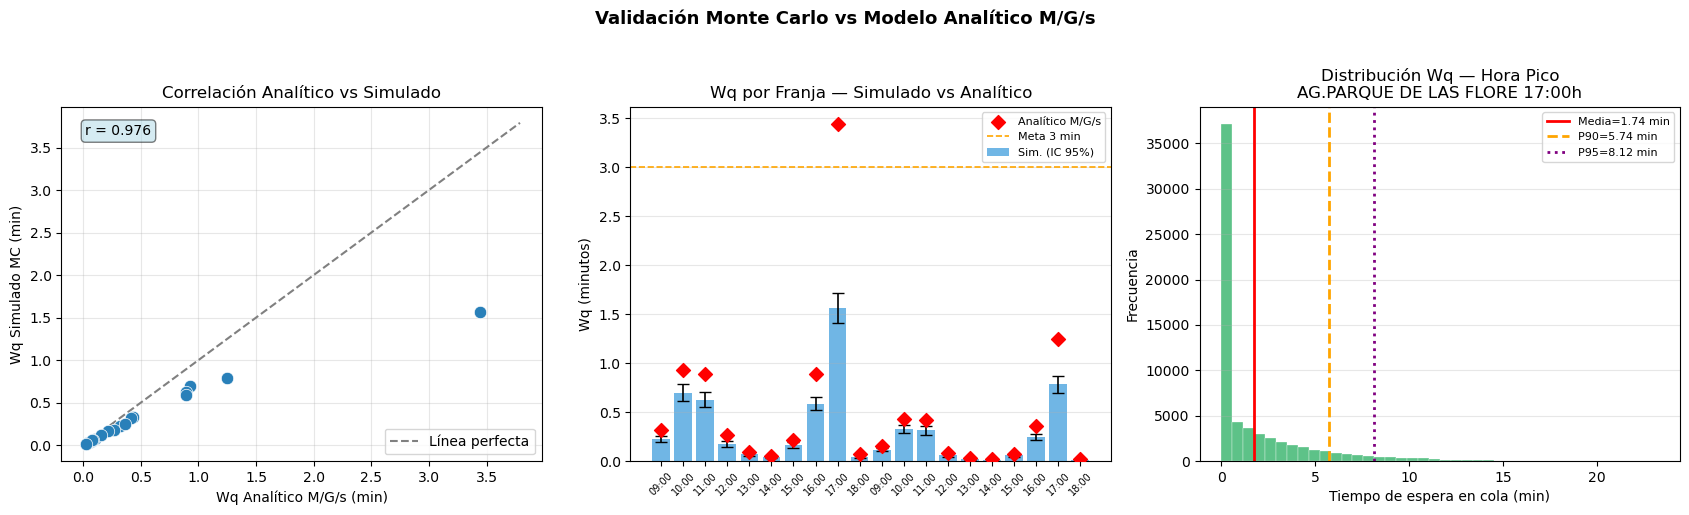


📊 Validación completada
  Correlación analítico-simulado: r = 0.9764
  Error medio absoluto: 0.1939 min

🏆 Hora pico: AG.PARQUE DE LAS FLORES L 17:00h
  Wq media simulada:  1.74 min
  Wq P90:             5.74 min
  Wq P95:             8.12 min


In [18]:
# ════════════════════════════════════════════════════════════
# VALIDACIÓN: Simulación vs Modelo Analítico M/G/s
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Validación Monte Carlo vs Modelo Analítico M/G/s', 
             fontsize=13, fontweight='bold', y=1.02)

valid = mc_df.dropna(subset=['Wq_mgs_analitico'])

# ── Gráfico 1: Scatter simulado vs analítico ──
ax = axes[0]
x = valid['Wq_mgs_analitico']
y = valid['Wq_sim_media']
ax.scatter(x, y, s=80, color='#2980b9', zorder=3, edgecolors='white', linewidth=0.5)
lim = max(x.max(), y.max()) * 1.1
ax.plot([0,lim],[0,lim],'--', color='gray', linewidth=1.5, label='Línea perfecta')
ax.set_xlabel('Wq Analítico M/G/s (min)')
ax.set_ylabel('Wq Simulado MC (min)')
ax.set_title('Correlación Analítico vs Simulado')
ax.legend(); ax.grid(alpha=0.3)

# R² simple
corr = np.corrcoef(x, y)[0,1]
ax.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# ── Gráfico 2: Barras con IC 95% por franja ──
ax = axes[1]
labels_bar = mc_df['hora'].str[:5] + '\n' + mc_df['agencia'].str.extract(r'(\w+)$')[0]
x_pos = np.arange(len(mc_df))
yerr = np.array([
    mc_df['Wq_sim_media'] - mc_df['Wq_sim_ci_low'],
    mc_df['Wq_sim_ci_high'] - mc_df['Wq_sim_media']
])
ax.bar(x_pos, mc_df['Wq_sim_media'], color='#3498db', alpha=0.7, 
       yerr=yerr, capsize=4, error_kw={'linewidth':1.2}, label='Sim. (IC 95%)')
ax.scatter(x_pos, mc_df['Wq_mgs_analitico'].fillna(0), 
           color='red', zorder=4, s=50, marker='D', label='Analítico M/G/s')
ax.set_xticks(x_pos); ax.set_xticklabels(mc_df['hora'].str[:5], rotation=45, fontsize=7)
ax.set_ylabel('Wq (minutos)')
ax.set_title('Wq por Franja — Simulado vs Analítico')
ax.axhline(3, color='orange', linestyle='--', linewidth=1.2, label='Meta 3 min')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# ── Gráfico 3: Distribución de Wq simulado — hora pico ──
ax = axes[2]
# Reconstruir simulación solo para la hora con más cola (máx Wq)
fila_pico = df2.loc[mc_df['Wq_sim_media'].idxmax()]
hora_pico_label = fila_pico['hora'][:5]
ag_pico_label   = fila_pico['agencia'][:25]

sub_dist = dist[dist['agencia'] == fila_pico['agencia']]
dist_hora_pico = {r2['tipo_ope']: float(r2[fila_pico['hora']]) 
                  for _, r2 in sub_dist.iterrows() if float(r2[fila_pico['hora']]) > 0}

# Guardar todas las réplicas del Wq (hora pico)
rng_pico = np.random.default_rng(999)
wq_reps = []
for rep in range(1000):  # más réplicas para histograma
    rng2 = np.random.default_rng(rep*17+3)
    lam  = fila_pico['lambda']
    n_arr = rng2.poisson(lam)
    if n_arr == 0: continue
    tipos = list(dist_hora_pico.keys())
    probs = np.array([dist_hora_pico[t] for t in tipos], dtype=float)
    probs /= probs.sum()
    tipos_asig = rng2.choice(tipos, size=n_arr, p=probs)
    t_srv = np.array([max(0.01, rng2.gamma(*gamma_params(T_SERVICIO[t], VAR_SERVICIO[t])))
                      for t in tipos_asig])
    s_ = int(fila_pico['servidores'])
    fin = np.zeros(s_)
    llegadas_ = np.sort(rng2.uniform(0, 60, n_arr))
    waits = []
    for i in range(n_arr):
        j = np.argmin(fin)
        t_ini = max(llegadas_[i], fin[j])
        waits.append(t_ini - llegadas_[i])
        fin[j] = t_ini + t_srv[i]
    wq_reps.extend(waits)

wq_arr = np.array(wq_reps)
ax.hist(wq_arr, bins=40, color='#27ae60', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(wq_arr.mean(), color='red', linewidth=2, label=f'Media={wq_arr.mean():.2f} min')
ax.axvline(np.percentile(wq_arr,90), color='orange', linewidth=2, linestyle='--',
           label=f'P90={np.percentile(wq_arr,90):.2f} min')
ax.axvline(np.percentile(wq_arr,95), color='purple', linewidth=2, linestyle=':',
           label=f'P95={np.percentile(wq_arr,95):.2f} min')
ax.set_xlabel('Tiempo de espera en cola (min)'); ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución Wq — Hora Pico\n{ag_pico_label[:22]} {hora_pico_label}h')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('mc_validacion.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\n📊 Validación completada')
print(f'  Correlación analítico-simulado: r = {corr:.4f}')
print(f'  Error medio absoluto: {abs(valid["Wq_mgs_analitico"] - valid["Wq_sim_media"]).mean():.4f} min')
print(f'\n🏆 Hora pico: {ag_pico_label} {hora_pico_label}h')
print(f'  Wq media simulada:  {wq_arr.mean():.2f} min')
print(f'  Wq P90:             {np.percentile(wq_arr,90):.2f} min')
print(f'  Wq P95:             {np.percentile(wq_arr,95):.2f} min')


  ANÁLISIS MC: Impacto de contratar auxiliar — Horas Críticas
  Agencia                        Hora   c    Wq_c  Wq_c+1  Mejora%  Ahorro_CT
-----------------------------------------------------------------
  ✅ AG.PARQUE DE LAS FLORES LO  10:00   5    0.67    0.19    71.2% S/.    4.62
  ✅ AG.PARQUE DE LAS FLORES LO  11:00   5    0.65    0.19    71.4% S/.    3.54
  ✅ AG.PARQUE DE LAS FLORES LO  16:00   5    0.65    0.18    71.6% S/.    3.55
  ✅ AG.PARQUE DE LAS FLORES LO  17:00   5    1.61    0.52    67.9% S/.   65.38
  ✅ AG. CIUDAD UNIVERSITARIA    17:00   6    0.80    0.25    68.6% S/.   12.25


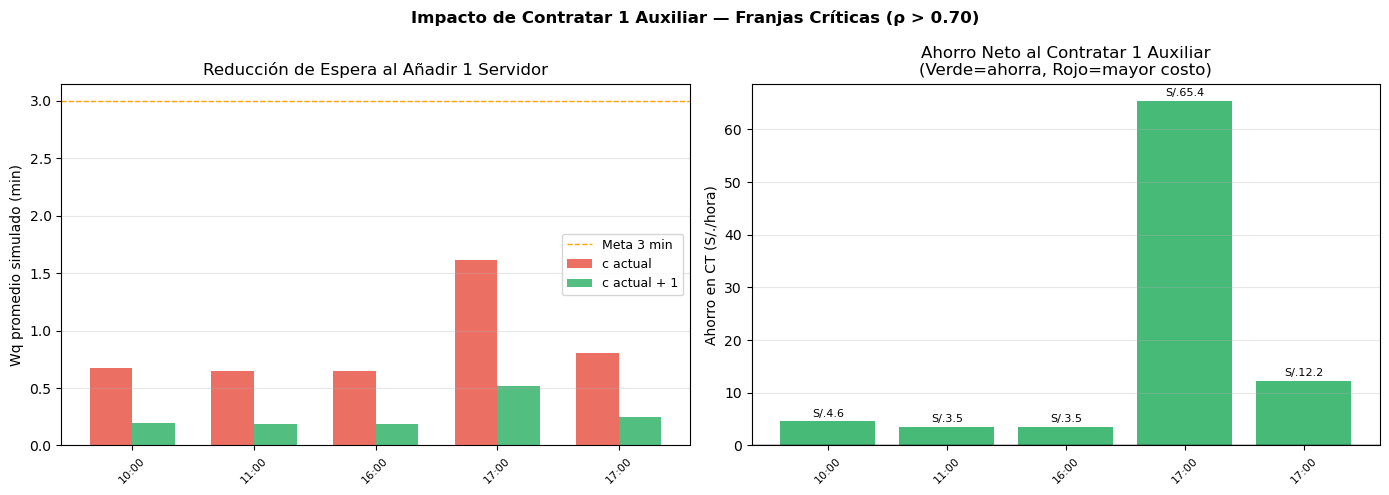


✅ Gráfico guardado: mc_impacto_auxiliar.png


In [19]:
# ════════════════════════════════════════════════════════════
# ANÁLISIS MONTE CARLO: Impacto de agregar 1 servidor extra
# ════════════════════════════════════════════════════════════
# Pregunta clave: ¿Cuánto mejora Wq si contramos 1 auxiliar en la hora pico?

print('='*65)
print('  ANÁLISIS MC: Impacto de contratar auxiliar — Horas Críticas')
print('='*65)
print(f'  {"Agencia":<28} {"Hora":>6} {"c":>3} {"Wq_c":>7} {"Wq_c+1":>7} {"Mejora%":>8} {"Ahorro_CT":>10}')
print('-'*65)

impacto_rows = []
# Solo franjas con rho > 0.75 (candidatas a contratar)
criticas = df2[df2.apply(
    lambda r: mms_metricas(r['lambda'],r['mu'],r['servidores'],r['Cs'],r['Cq'])['rho'] > 0.70 
              if r['mu']>0 else False, axis=1)]

for _, row in criticas.iterrows():
    sub_dist = dist[dist['agencia'] == row['agencia']]
    dist_h   = {r2['tipo_ope']: float(r2[row['hora']]) 
                for _, r2 in sub_dist.iterrows() if float(r2[row['hora']]) > 0}
    c_actual = int(row['servidores'])
    
    res_c   = simular_cola_mc(row['lambda'], row['mu'], c_actual,
                               t_ops, dist_h, n_rep=400, seed=7)
    res_c1  = simular_cola_mc(row['lambda'], row['mu'], c_actual+1,
                               t_ops, dist_h, n_rep=400, seed=8)
    
    wq_c    = res_c['Wq_m']['media']
    wq_c1   = res_c1['Wq_m']['media']
    mejora  = (wq_c - wq_c1) / wq_c * 100 if wq_c > 0 else 0
    
    # Costo diferencial
    mg_c    = mgs_metricas(row['lambda'],row['mu'],c_actual,row['Cs'],row['Cq'],row['C_s2'])
    mg_c1   = mgs_metricas(row['lambda'],row['mu'],c_actual+1,row['Cs'],row['Cq'],row['C_s2'])
    ahorro  = (mg_c['CT_mg'] - mg_c1['CT_mg']) if not np.isnan(mg_c['CT_mg']) and not np.isnan(mg_c1['CT_mg']) else np.nan
    
    impacto_rows.append({
        'agencia': row['agencia'], 'hora': row['hora'],
        'c_actual': c_actual, 'c_propuesto': c_actual+1,
        'Wq_c': round(wq_c,3), 'Wq_c1': round(wq_c1,3),
        'mejora_pct': round(mejora,1),
        'ahorro_CT_hora': round(ahorro,2) if not np.isnan(ahorro) else np.nan,
        'viable': ahorro > 0 if not np.isnan(ahorro) else False
    })
    
    signo = '✅' if not np.isnan(ahorro) and ahorro > 0 else '⚠️ '
    print(f'  {signo} {row["agencia"][:26]:<26} {row["hora"][:5]:>6} {c_actual:>3} '
          f'{wq_c:>7.2f} {wq_c1:>7.2f} {mejora:>7.1f}% '
          f'S/.{ahorro if not np.isnan(ahorro) else 0:>8.2f}')

impacto_df = pd.DataFrame(impacto_rows)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto de Contratar 1 Auxiliar — Franjas Críticas (ρ > 0.70)',
             fontsize=12, fontweight='bold')

# Reducción de Wq
ax = axes[0]
x_pos = np.arange(len(impacto_df))
w = 0.35
ax.bar(x_pos - w/2, impacto_df['Wq_c'],  w, label='c actual',      color='#e74c3c', alpha=0.8)
ax.bar(x_pos + w/2, impacto_df['Wq_c1'], w, label='c actual + 1',  color='#27ae60', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(impacto_df['hora'].str[:5], rotation=45, fontsize=8)
ax.set_ylabel('Wq promedio simulado (min)')
ax.set_title('Reducción de Espera al Añadir 1 Servidor')
ax.axhline(3, color='orange', linestyle='--', linewidth=1, label='Meta 3 min')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

# Ahorro de costo
ax = axes[1]
colors_bar = ['#27ae60' if v else '#e74c3c' for v in impacto_df['viable']]
bars = ax.bar(x_pos, impacto_df['ahorro_CT_hora'].fillna(0), color=colors_bar, alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(impacto_df['hora'].str[:5], rotation=45, fontsize=8)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Ahorro en CT (S/./hora)')
ax.set_title('Ahorro Neto al Contratar 1 Auxiliar\n(Verde=ahorra, Rojo=mayor costo)')
for bar, v in zip(bars, impacto_df['ahorro_CT_hora'].fillna(0)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
            f'S/.{v:.1f}', ha='center', va='bottom', fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('mc_impacto_auxiliar.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n✅ Gráfico guardado: mc_impacto_auxiliar.png')


In [27]:
# ════════════════════════════════════════════════════════════
# EXPORTAR RESULTADOS MC A CSV PARA POWER BI
# ════════════════════════════════════════════════════════════

mc_df.to_csv('powerbi_montecarlo.csv', index=False, encoding='utf-8-sig')
impacto_df.to_csv('powerbi_impacto_auxiliar.csv', index=False, encoding='utf-8-sig')

print('✅ powerbi_montecarlo.csv     → métricas simuladas (Wq media, std, IC95, P50/P90/P95)')
print('✅ powerbi_impacto_auxiliar.csv → análisis contratar 1 auxiliar')
print()
print('=== RESUMEN EJECUTIVO — SIMULACIÓN MONTE CARLO ===')
print()
print(f'  Réplicas por franja:    {N_REP}')
print(f'  Franjas analizadas:     {len(mc_df)}')
print(f'  Wq promedio global:     {mc_df["Wq_sim_media"].mean():.2f} min')
print(f'  Wq P90 global (peor):  {mc_df["Wq_sim_p90"].mean():.2f} min')
print(f'  Franjas con Wq > 3 min: {(mc_df["Wq_sim_media"] > 3).sum()}')
print()

# Tabla resumen para gerencia
print('  {:<28} {:>6} {:>8} {:>8} {:>8} {:>8}'.format(
      'Agencia', 'Hora', 'Wq_med', 'IC_low', 'IC_high', 'P90'))
print('  ' + '-'*68)
for _, r in mc_df.iterrows():
    flag = '🔴' if r['Wq_sim_media'] > 3 else ('🟡' if r['Wq_sim_media'] > 1.5 else '🟢')
    print(f'  {flag} {r["agencia"][:26]:<26} {r["hora"][:5]:>6} '
          f'{r["Wq_sim_media"]:>7.2f} {r["Wq_sim_ci_low"]:>7.2f}'
          f' {r["Wq_sim_ci_high"]:>8.2f} {r["Wq_sim_p90"]:>8.2f}')


✅ powerbi_montecarlo.csv     → métricas simuladas (Wq media, std, IC95, P50/P90/P95)
✅ powerbi_impacto_auxiliar.csv → análisis contratar 1 auxiliar

=== RESUMEN EJECUTIVO — SIMULACIÓN MONTE CARLO ===

  Réplicas por franja:    500
  Franjas analizadas:     20
  Wq promedio global:     0.31 min
  Wq P90 global (peor):  0.76 min
  Franjas con Wq > 3 min: 0

  Agencia                        Hora   Wq_med   IC_low  IC_high      P90
  --------------------------------------------------------------------
  🟢 AG.PARQUE DE LAS FLORES LO  09:00    0.23    0.20     0.26     0.56
  🟢 AG.PARQUE DE LAS FLORES LO  10:00    0.70    0.61     0.79     1.72
  🟢 AG.PARQUE DE LAS FLORES LO  11:00    0.63    0.55     0.71     1.59
  🟢 AG.PARQUE DE LAS FLORES LO  12:00    0.17    0.14     0.20     0.44
  🟢 AG.PARQUE DE LAS FLORES LO  13:00    0.07    0.06     0.09     0.21
  🟢 AG.PARQUE DE LAS FLORES LO  14:00    0.04    0.03     0.05     0.12
  🟢 AG.PARQUE DE LAS FLORES LO  15:00    0.16    0.13     0.19   

---
## PASO 12 — Exportar dataset final para Power BI

Generamos tres tablas:
1. **powerbi_principal.csv** → métricas completas por agencia-hora
2. **powerbi_sensibilidad.csv** → escenarios para análisis de sensibilidad
3. **powerbi_resumen_agencia.csv** → KPIs agregados por agencia

In [28]:
# Tabla 1: Principal
result_df.to_csv('powerbi_principal.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_principal.csv      → {result_df.shape[0]} filas, {result_df.shape[1]} cols')

# Tabla 2: Sensibilidad
sens_df.to_csv('powerbi_sensibilidad.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_sensibilidad.csv   → {sens_df.shape[0]} filas')

# Tabla 3: Resumen por agencia
resumen = result_df.groupby('agencia').agg(
    horas_analizadas    = ('hora','count'),
    lambda_promedio     = ('lambda','mean'),
    mu_promedio         = ('mu','mean'),
    rho_promedio        = ('rho','mean'),
    serv_actuales_prom  = ('servidores_actuales','mean'),
    serv_optimos_prom   = ('servidores_optimos','mean'),
    Wq_m_promedio       = ('Wq_m_mgs','mean'),
    CT_actual_total     = ('CT_actual','sum'),
    CT_optimo_total     = ('CT_optimo','sum'),
    ahorro_total        = ('ahorro_potencial','sum'),
    horas_contratar     = ('contratar_auxiliar', lambda x: (x=='SÍ').sum())
).round(2).reset_index()

resumen['pct_ahorro'] = (resumen['ahorro_total'] / resumen['CT_actual_total'] * 100).round(1)
resumen.to_csv('powerbi_resumen_agencia.csv', index=False, encoding='utf-8-sig')
print(f'✅ powerbi_resumen_agencia.csv → {resumen.shape[0]} filas')
print()
print(resumen[['agencia','CT_actual_total','CT_optimo_total','ahorro_total','pct_ahorro','horas_contratar']].to_string(index=False))

✅ powerbi_principal.csv      → 20 filas, 31 cols
✅ powerbi_sensibilidad.csv   → 100 filas
✅ powerbi_resumen_agencia.csv → 2 filas

                              agencia  CT_actual_total  CT_optimo_total  ahorro_total  pct_ahorro  horas_contratar
             AG. CIUDAD UNIVERSITARIA        1639.7600        1548.4300       91.3100      5.6000                1
AG.PARQUE DE LAS FLORES LOS GUINDALES        1669.3300        1559.2600      110.0800      6.6000                4


---
## PASO 13 — Visualizaciones finales (resumen ejecutivo)

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(16,11))
fig.suptitle('Resumen Ejecutivo — Optimización de Servidores Bancarios',fontsize=14,fontweight='bold')

agencias = result_df['agencia'].unique()
colores2 = ['#3498db','#e74c3c']

# Plot 1: Servidores actuales vs óptimos
ax = axes[0,0]
for i,(agencia,col) in enumerate(zip(agencias,colores2)):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    x   = np.arange(len(hrs)) + i*0.35
    ax.bar(x,     sub['servidores_actuales'],width=0.3,color=col,alpha=0.9,label=f'Actual-{agencia[:12]}')
    ax.bar(x+0.3, sub['servidores_optimos'], width=0.3,color=col,alpha=0.45,label=f'Óptimo-{agencia[:12]}')
ax.set_xticks(np.arange(10)+0.35)
ax.set_xticklabels([h.split(' ')[0] for h in result_df[result_df['agencia']==agencias[0]]['hora']],rotation=45,fontsize=8)
ax.set_title('Servidores: Actual vs Óptimo')
ax.set_ylabel('Nº Servidores')
ax.legend(fontsize=7)
ax.grid(axis='y',alpha=0.3)

# Plot 2: Tiempo de espera
ax = axes[0,1]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    ax.plot(hrs,sub['Wq_m_mgs'],'o-',color=col,linewidth=2,label=agencia[:25],markersize=6)
ax.axhline(5,color='gray',linestyle='--',linewidth=1,label='Umbral 5 min')
ax.set_title('Tiempo de Espera en Cola (M/G/s)')
ax.set_ylabel('Wq (minutos)')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Plot 3: CT actual vs óptimo
ax = axes[1,0]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    ax.fill_between(hrs,sub['CT_actual'],sub['CT_optimo'],alpha=0.25,color=col)
    ax.plot(hrs,sub['CT_actual'],'o-',color=col,linewidth=2,markersize=5,label=f'Actual {agencia[:12]}')
    ax.plot(hrs,sub['CT_optimo'],'s--',color=col,linewidth=1.5,markersize=5,label=f'Óptimo {agencia[:12]}')
ax.set_title('Costo Total: Actual vs Óptimo\n(área sombreada = ahorro posible)')
ax.set_ylabel('Costo Total S/.')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Plot 4: Ahorro potencial
ax = axes[1,1]
for agencia,col in zip(agencias,colores2):
    sub = result_df[result_df['agencia']==agencia]
    hrs = [h.split(' ')[0] for h in sub['hora']]
    bars = ax.bar(hrs,sub['ahorro_potencial'],color=col,alpha=0.7,label=agencia[:25])
    for bar,dec in zip(bars,sub['decision']):
        if dec!='MANTENER':
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
                    dec,ha='center',fontsize=6,rotation=45)
ax.set_title('Ahorro Potencial por Franja Horaria')
ax.set_ylabel('Ahorro S/.')
ax.tick_params(axis='x',rotation=45)
ax.legend(fontsize=7)
ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_resumen.png',dpi=130,bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: dashboard_resumen.png')

---
## PASO 14 — Conclusiones e Informe Ejecutivo

In [ ]:
print('='*70)
print('   INFORME EJECUTIVO — OPTIMIZACIÓN DE SERVIDORES BANCARIOS')
print('='*70)

for _, row_res in resumen.iterrows():
    print(f"\n📍 AGENCIA: {row_res['agencia']}")
    print(f"   Costo Total Actual  : S/. {row_res['CT_actual_total']:.2f}/día")
    print(f"   Costo Total Óptimo  : S/. {row_res['CT_optimo_total']:.2f}/día")
    print(f"   Ahorro Potencial    : S/. {row_res['ahorro_total']:.2f}/día ({row_res['pct_ahorro']}%)")
    print(f"   Horas c/ auxiliar adicional recomendado: {int(row_res['horas_contratar'])} de 10")

print()
print('-'*70)
print('DETALLE DE DECISIONES:')
print('-'*70)
cols = ['agencia','hora','servidores_actuales','servidores_optimos',
        'Wq_m_mgs','CT_actual','ahorro_potencial','decision']
print(result_df[cols].to_string(index=False))
print()
print('NOTA METODOLÓGICA:')
print('C_s² < 1 en todos los casos → los tiempos de servicio son más regulares')
print('que un proceso exponencial puro → las colas reales son menores a M/M/s.')
print('El modelo M/G/s (Allen-Cunneen) es más preciso para este contexto bancario.')

---
## 📊 Propuesta de Dashboard Power BI

### Tablas a importar:
| Archivo | Uso en Power BI |
|---------|----------------|
| `powerbi_principal.csv` | Tabla central (20 filas) con todas las métricas |
| `powerbi_sensibilidad.csv` | Tabla para análisis de escenarios (100 filas) |
| `powerbi_resumen_agencia.csv` | Tabla de KPIs por agencia (2 filas) |

### Páginas sugeridas:

**Página 1 — Decisión de Contratación (para gerencia)**
- Tarjetas KPI: Ahorro Total Potencial | Horas donde contratar | Costo actual vs óptimo
- Tabla con columna de semáforo: CONTRATAR / MANTENER / REDUCIR
- Filtros: Agencia | Hora

**Página 2 — Tiempos y Colas**
- Gráfico de líneas: Wq_m_mgs por hora (comparativo entre agencias)
- Gráfico de barras: servidores_ociosos vs servidores_ocupados apilados
- KPI: rho promedio (utilización)

**Página 3 — Costos Detallados**
- Gráfico apilado: CTS + CTS_idle + CTQ por hora
- Comparativo barras: CT_actual vs CT_optimo
- Tabla de ahorro_potencial por hora

**Página 4 — Análisis de Sensibilidad**
- Gráfico de líneas: CT_var por escenario (-20% a +20%)
- Segmentador de hora y agencia
- Anotaciones con s_opt_var

### Medidas DAX sugeridas:
```dax
Ahorro_Total = SUM(powerbi_principal[ahorro_potencial])
Utilizacion_Prom = AVERAGE(powerbi_principal[util_pct])
Horas_Contratar = COUNTROWS(FILTER(powerbi_principal, powerbi_principal[contratar_auxiliar] = "SÍ"))
CT_Actual_Total = SUM(powerbi_principal[CT_actual])
CT_Optimo_Total = SUM(powerbi_principal[CT_optimo])
Pct_Ahorro = DIVIDE([Ahorro_Total], [CT_Actual_Total], 0) * 100
```